In [2]:
#Install Kaggle
!pip install kaggle --quiet

In [3]:
#Upload Kaggle.Json File
from google.colab import files
files.upload()

{}

In [4]:
#Create the Kaggle Directory
!mkdir ~/.kaggle

In [5]:
#Copy the Kagge.json file
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [6]:
!chmod 600 /root/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [7]:
#Download the dataset
!kaggle datasets download -d 'aditya126/basic-maths-symbols-dataset' -p ../data/MathSymbols

Dataset URL: https://www.kaggle.com/datasets/aditya126/basic-maths-symbols-dataset
License(s): ODbL-1.0
100% 54.9M/54.9M [00:02<00:00, 22.5MB/s]



In [8]:
#Unzip the dataset
!unzip ../data/MathSymbols/basic-maths-symbols-dataset.zip -d ../data/MathSymbols/

Streaming output truncated to the last 5000 lines.
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3248.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3249.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_325.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3250.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3251.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3252.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3253.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3254.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3255.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3256.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3257.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3258.png  
  inflating: ../data/MathSymbols/symbol_dataset/times/times_3259.png  
  inflating: ../data/MathSy

In [9]:
!ls -ltr ../data/MathSymbols/

total 56212
-rw-r--r--  1 root root 57553393 Feb 10  2025 basic-maths-symbols-dataset.zip
drwxr-xr-x 10 root root     4096 Jun 26 05:56 symbol_dataset


In [10]:
!chmod 777 ../data/MathSymbols/basic-maths-symbols-dataset.zip

In [11]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Path to dataset root (adjust if needed)
DATASET_PATH = "../data/MathSymbols/symbol_dataset"

# Map folder names to symbols
label_map = {
    "plus": "+",
    "minus": "-",
    "multiply": "*",
    "divide": "/",
    "equals": "=",
    "times": "x",
    "open_bracket": "(",
    "close_bracket": ")"
}

# Allowed classes (exclude brackets, times)
allowed_classes = ["+", "-", "*", "/"]

IMG_SIZE = 28
X, y = [], []

# Loop through folders
for folder, symbol in label_map.items():
    if symbol not in allowed_classes:
        continue  # skip brackets

    folder_path = os.path.join(DATASET_PATH, folder)
    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)

        # Read grayscale image
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        # Resize (just to be safe)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Normalize
        img = img / 255.0

        X.append(img)
        y.append(allowed_classes.index(symbol))

# Convert to numpy arrays
X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y = np.array(y)

# One-hot encode labels
y = to_categorical(y, num_classes=len(allowed_classes))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Classes:", allowed_classes)

Training set shape: (24000, 28, 28, 1)
Test set shape: (6000, 28, 28, 1)
Classes: ['+', '-', '*', '/']


In [12]:
for idx, name in enumerate(allowed_classes):
    print(f"Index {idx} maps to character: '{name}'")

Index 0 maps to character: '+'
Index 1 maps to character: '-'
Index 2 maps to character: '*'
Index 3 maps to character: '/'


In [13]:
np.save("/content/X.npy", X)
np.save("/content/y.npy", y)

In [14]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(4, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,        # fixed number of epochs
    batch_size=32,
    verbose=1
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9916 - loss: 0.0228 - val_accuracy: 1.0000 - val_loss: 4.0885e-06
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 1.0000 - loss: 2.7370e-06 - val_accuracy: 1.0000 - val_loss: 1.8348e-06
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 1.0000 - loss: 1.3374e-06 - val_accuracy: 1.0000 - val_loss: 9.4697e-07
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 1.0000 - loss: 7.3636e-07 - val_accuracy: 1.0000 - val_loss: 5.3404e-07
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 1.0000 - loss: 4.2154e-07 - val_accuracy: 1.0000 - val_loss: 3.1565e-07
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 1.0000 - loss: 2.5279e-07 - val_accuracy: 1.0000 - val_loss: 1.9425e-07
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 1.0000 - loss: 1.5301e-07 - val_accuracy: 1.0000 - val_loss: 1.1462e-07
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step 

In [17]:
model.save("symbol_model.keras")

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


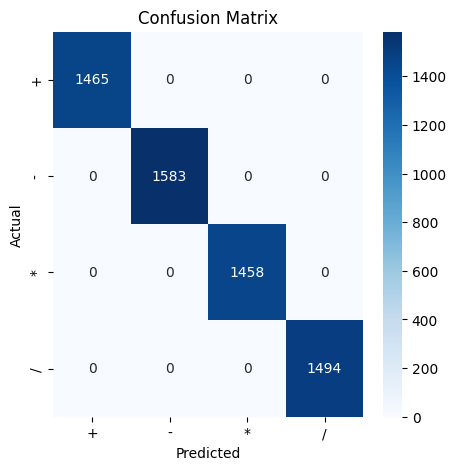

In [18]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Predict
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['+', '-', '*', '/'],
            yticklabels=['+', '-', '*', '/'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

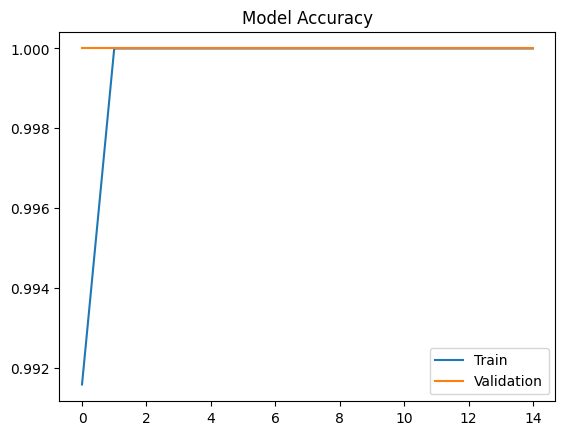

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [20]:
print(os.listdir("/content"))

['.config', 'X.npy', 'symbol_model.keras', 'y.npy', 'sample_data']


In [21]:
from google.colab import files
files.download("symbol_model.keras")
files.download("X.npy")
files.download("y.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Digits_model training

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape and normalize
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# One-hot encode labels (10 digits)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),                     # helps prevent overfitting
    Dense(10, activation='softmax')   # 10 outputs for digits 0–9
])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train (fixed epochs, no early stopping)
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=20,          # fixed number of epochs
    batch_size=128,
    verbose=1
)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.4f}")

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9130 - loss: 0.2825 - val_accuracy: 0.9757 - val_loss: 0.0766
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9766 - loss: 0.0783 - val_accuracy: 0.9870 - val_loss: 0.0388
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9838 - loss: 0.0556 - val_accuracy: 0.9839 - val_loss: 0.0506
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9880 - loss: 0.0420 - val_accuracy: 0.9897 - val_loss: 0.0291
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9901 - loss: 0.0341 - val_accuracy: 0.9918 - val_loss: 0.0252
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9911 - loss: 0.0299 - val_accuracy: 0.9913 - val_loss: 0.0261
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9927 - loss: 0.0246 - val_accuracy: 0.9926 - val_loss: 0.0247
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9934 - loss: 0.0210 - val_accuracy: 

In [24]:
# Save model
model.save("mnist_digit_model.keras")

In [25]:
from google.colab import files
files.download("mnist_digit_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

(alternate) combining both digits and symbols into single dataset

In [12]:
import os
import cv2
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Step 1: Define unified classes (digits + 4 symbols)
all_classes = ['0','1','2','3','4','5','6','7','8','9',
               '+','-','*','/']   # 14 total classes

# Map symbol folders to unified indices
symbol_map = {'plus':10, 'minus':11, 'multiply':12, 'divide':13}

IMG_SIZE = 28
DATASET_PATH = "../data/MathSymbols/symbol_dataset"

# Step 2: Load digits (MNIST)
(x_train_d, y_train_d), (x_test_d, y_test_d) = mnist.load_data()
x_digits = np.concatenate([x_train_d, x_test_d])
y_digits = np.concatenate([y_train_d, y_test_d])

# Preprocess digits
x_digits = x_digits.reshape(-1, IMG_SIZE, IMG_SIZE, 1).astype("float32")/255.0
# Labels already 0–9, no remap needed

# Step 3: Load symbols (only +, -, *, /)
X_sym, y_sym = [], []
for folder, idx in symbol_map.items():
    folder_path = os.path.join(DATASET_PATH, folder)
    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        X_sym.append(img)
        y_sym.append(idx)

X_sym = np.array(X_sym).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y_sym = np.array(y_sym)

# Step 4: Merge digits + symbols
X = np.concatenate([x_digits, X_sym])
y = np.concatenate([y_digits, y_sym])

# One-hot encode labels for 14 classes
y = to_categorical(y, num_classes=len(all_classes))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Classes:", all_classes)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set shape: (80000, 28, 28, 1)
Test set shape: (20000, 28, 28, 1)
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', '*', '/']


In [13]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(all_classes),activation='softmax')  # 14 outputs
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    validation_data=(X_test,y_test),
                    epochs=20,
                    batch_size=128,
                    verbose=1)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9255 - loss: 0.2558 - val_accuracy: 0.9838 - val_loss: 0.0534
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9833 - loss: 0.0584 - val_accuracy: 0.9888 - val_loss: 0.0359
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9887 - loss: 0.0391 - val_accuracy: 0.9914 - val_loss: 0.0285
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9902 - loss: 0.0332 - val_accuracy: 0.9908 - val_loss: 0.0301
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9923 - loss: 0.0262 - val_accuracy: 0.9911 - val_loss: 0.0339
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9936 - loss: 0.0224 - val_accuracy: 0.9928 - val_loss: 0.0258
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9945 - loss: 0.0186 - val_accuracy: 0.9929 - val_loss: 0.0285
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9951 - loss: 0.0162 - val_accuracy: 0

In [15]:
# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.4f}")

# Save model
model.save("digits_symbols_model.keras")

Test accuracy: 0.9941


In [30]:
from google.colab import files
files.download("digits_symbols_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
for idx, name in enumerate(all_classes):
    print(f"Index {idx} maps to character: '{name}'")


Index 0 maps to character: '0'
Index 1 maps to character: '1'
Index 2 maps to character: '2'
Index 3 maps to character: '3'
Index 4 maps to character: '4'
Index 5 maps to character: '5'
Index 6 maps to character: '6'
Index 7 maps to character: '7'
Index 8 maps to character: '8'
Index 9 maps to character: '9'
Index 10 maps to character: '+'
Index 11 maps to character: '-'
Index 12 maps to character: '*'
Index 13 maps to character: '/'


In [17]:
import matplotlib.pyplot as plt
# Check if the pixel values are mostly 0 (black background) or 1 (white background)
print("Average pixel value of a symbol:", np.mean(X_sym[0]))


Average pixel value of a symbol: 0.10793817527010804
